In [1]:
using Pkg
ENV["JULIA_REVISE_POLL"]="1"
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
using Revise;

  Activating project at `~/Github_Projects/JJDFTX.jl`


In [3]:
using PyPlot, PyCall, JJDFTX, LinearAlgebra
interpolate = pyimport("scipy.interpolate").interp1d;
using JJDFTX: fermi, bose

### Plot of Sodium intercalant band structure 

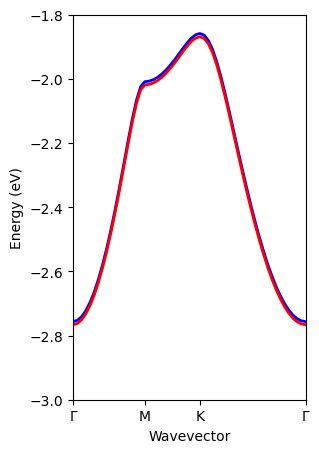

In [4]:
figure(figsize=(3, 5))
plot_bands("Na-bands.eigenvals", spin=2, linewidth=2, whichbands=[61])
ylim(-3, -1.8);

### Zoomed out version of same band structure 

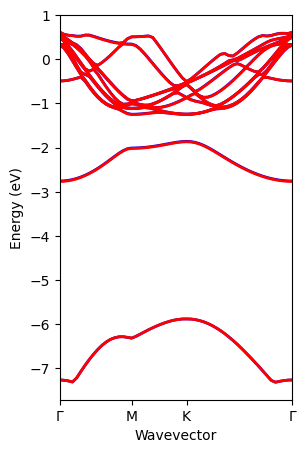

In [5]:
figure(figsize=(3, 5))
plot_bands("Na-bands.eigenvals", spin=2, linewidth=2, whichbands=[60, 61:70...]);
#ylim(-2.77, -1.25);

### Plot of phonon band structure (Corresponds to Figure 2a of the paper)

In [6]:
force_matrix, cellph_map = phonon_force_matrix("Na");
dispersion = phonon_dispersion(force_matrix, cellph_map, return_negative=true);

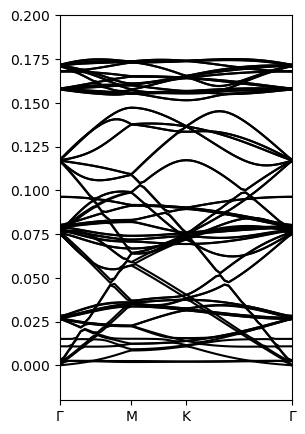

In [7]:
figure(figsize=(3, 5))
label_plots()
plot(dispersion, color="black");
ylim(-0.02, 0.2);
#savefig("Moire-Phonons.pdf")

### Now we display the maximum phonon energy, which determines the phase space for the lowest order electron-phonon assisted losses 

In [8]:
max_phonon_dispersion = maximum(dispersion)
println("Maximum phonon energy: ", round(max_phonon_dispersion, digits=6), " eV");

Maximum phonon energy: 0.174983 eV


### Now we calculate the Wannier band structure 

In [9]:
Hwannier, cell_map = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt");
kpoints = bandstructkpoints2q(interpolate=6);
lattice_vectors = loadlattice("wannier.out");

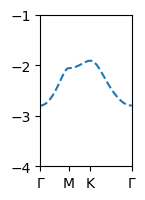

In [10]:
cm = 1/2.54
figure(figsize=(3*cm, 5*cm))
plot_bands(Hwannier, cell_map, linestyle="dashed")
label_plots()
ylim(-4, -1);

### Calculate chemical potentials for filling factors of interest

In [11]:
Es, Ds = density_of_states(Hwannier, cell_map, Val(2), mesh=30, num_blocks=1000, monte_carlo=true, histogram_width=100);

In [12]:
es, cs = find_chemical_potential(Es, Ds);

In [13]:
μ3 = es[argmin(abs.(cs .- 0.3))]
μ4 = es[argmin(abs.(cs .- 0.4))]
μ5 = es[argmin(abs.(cs .- 0.5))]
μ1 = es[argmin(abs.(cs .- 0.1))]
μ2 = es[argmin(abs.(cs .- 0.2))];

### Equivalent to Figure 2c below

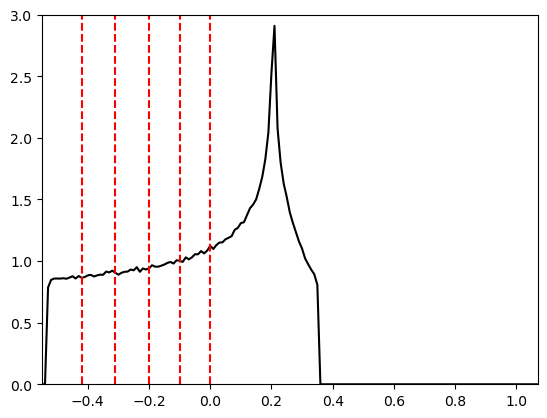

In [14]:
plot(Es .- μ5, Ds, color="black")
vlines(μ1-μ5, 0, 3, color="red", linestyle="dashed")
vlines(μ2-μ5, 0, 3, color="red", linestyle="dashed")
vlines(μ3-μ5, 0, 3, color="red", linestyle="dashed")
vlines(μ4-μ5, 0, 3, color="red", linestyle="dashed")
vlines(μ5-μ5, 0, 3, color="red", linestyle="dashed")
vlines(-1.24, 0, 3, color="black", linestyle="dotted")
ylim(0, 3)
xlim(-0.55, 1.07);
#xticks([-2.8, -2.4, -2, -1.6, -1.2], round.([-2.8, -2.4, -2, -1.6, -1.2] .- μ5, digits=2))
#savefig("overlayed_dos.pdf")

### Now we calculate the polarization function. The chemical potentials used below are calculated some cell blocks down. They correspond to filling factors of $0.1, 0.2, 0.3, 0.4, 0.5$. 

In [15]:
polarizations_mu = []
for (mu_idx, mu) in enumerate([μ1, μ2, μ3, μ4, μ5])
    println("mu_idx: ", mu_idx); flush(stdout); 
    polarizations = []
    for (i,k) in enumerate(kpoints[1:300])
        if (i%100) == 0
            println("kpoint index: ", i); flush(stdout);
        end
        polarization_up = ImΠ(Hwannier, cell_map, lattice_vectors, k, mu, Val(2), histogram_width=100, mesh=60, 
                degeneracy=2, monte_carlo=true, verbose=false)
        push!(polarizations, polarization_up)
    end
    push!(polarizations_mu, polarizations)
end

mu_idx: 1
kpoint index: 100
kpoint index: 200
kpoint index: 300
mu_idx: 2
kpoint index: 100
kpoint index: 200
kpoint index: 300
mu_idx: 3
kpoint index: 100
kpoint index: 200
kpoint index: 300
mu_idx: 4
kpoint index: 100
kpoint index: 200
kpoint index: 300
mu_idx: 5
kpoint index: 100
kpoint index: 200
kpoint index: 300


In [17]:
energies = range(0, 100, length=10000)
energies = collect(energies)
epsilons_default_mu = []
for (mu_idx, mu) in enumerate([μ1, μ2, μ3, μ4, μ5])
    epsilons_default = zeros(300, 100)
    for (i, k) in enumerate(kpoints[1:300])
        i == 1 && continue
        if (i%100) == 0
            println(i); flush(stdout)
        end
        for (j, ω) in enumerate(range(0.05, 2, length=100))
            epsilons_default[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations_mu[mu_idx][i]), win_len=1), Val(2), Val(:default), limit=20, δ=0.001, normalized=true))
        end
    end
    push!(epsilons_default_mu, epsilons_default)
end

100
200
300
100
200
300
100
200
300
100
200
300
100
200
300


In [18]:
plasmon_mu = []
confinements_mu = []
qs_mu = []
win_len=10
for mu_idx in 1:5
    plasmon_default = [range(0.05, 2, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_default_mu[mu_idx][2:300, :])))];
    plasmon_default = [0, plasmon_default...]
    qs, confinements = confinement(lattice_vectors, kpoints[1:300], plasmon_default);
    plasmon_default = smooth(plasmon_default, win_len=1);
    plasmon_default[1] = 0;
    push!(plasmon_mu, plasmon_default)
    push!(qs_mu, qs)
    push!(confinements_mu, confinements)
end

In [19]:
plasmon_mu_smoothed = []
win_len = 20
for mu_idx in 1:5
    plasmon_smooth = smooth(plasmon_mu[mu_idx], win_len=win_len);
    plasmon_smooth[1] = 0;
    push!(plasmon_mu_smoothed, plasmon_smooth)
end

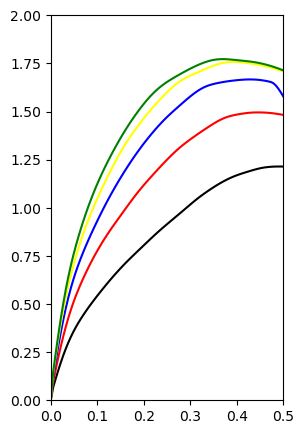

In [20]:
figure(figsize=(3, 5))
max_idx = 100 
plot(qs_mu[1][1:max_idx],plasmon_mu_smoothed[1][1:max_idx], color="black")
plot(qs_mu[2][1:max_idx],plasmon_mu_smoothed[2][1:max_idx], color="red")
plot(qs_mu[3][1:max_idx],plasmon_mu_smoothed[3][1:max_idx], color="blue")
plot(qs_mu[4][1:max_idx],plasmon_mu_smoothed[4][1:max_idx], color="yellow")
plot(qs_mu[5][1:max_idx],plasmon_mu_smoothed[5][1:max_idx], color="green")
ylim(0, 2)
xlim(0, 0.5);

In [21]:
d = 3
qs = qs_mu[1]
eps_hbn = [q < 0.3 ? 1+(2/0.3)*q : 3 for q in qs]
screening = (exp.(qs*d) + cosh.(qs*d).*(2eps_hbn.-1))./(exp.(qs*d) + sinh.(qs*d).*(2eps_hbn.-1));

### Plasmon dispersion with screening (Figure 2b)

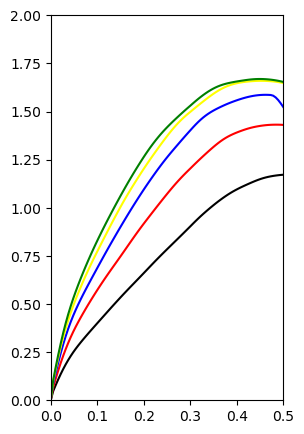

In [23]:
figure(figsize=(3, 5))
max_idx = 100 
plot(qs_mu[1][1:max_idx],plasmon_mu_smoothed[1][1:max_idx]./sqrt.(screening)[1:max_idx], color="black")
plot(qs_mu[2][1:max_idx],plasmon_mu_smoothed[2][1:max_idx]./sqrt.(screening)[1:max_idx], color="red")
plot(qs_mu[3][1:max_idx],plasmon_mu_smoothed[3][1:max_idx]./sqrt.(screening)[1:max_idx], color="blue")
plot(qs_mu[4][1:max_idx],plasmon_mu_smoothed[4][1:max_idx]./sqrt.(screening)[1:max_idx], color="yellow")
plot(qs_mu[5][1:max_idx],plasmon_mu_smoothed[5][1:max_idx]./sqrt.(screening)[1:max_idx], color="green")
ylim(0, 2)
xlim(0, 0.5);
#savefig("Plasmon-5mus.pdf");